In [1]:
import pandas as pd

input_file = "bookings.xlsx"
output_file = "bookings.csv"

df = pd.read_excel(input_file)
df.to_csv(output_file, index=False)

print(f"Converted '{input_file}' to '{output_file}'")

/Users/lottebecking/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Converted 'bookings.xlsx' to 'bookings.csv'


In [5]:
import re
from collections import Counter

columns = ["other_experiences", "other_focus"]

# Basic stopwords (NL + EN) for token-level analysis
stopwords = {
    "de", "het", "een", "en", "van", "op", "in", "met", "voor", "aan", "bij", "te",
    "we", "wij", "ons", "onze", "is", "zijn", "hebben", "heeft", "nog", "geen",
    "the", "and", "for", "with", "that", "this", "are", "our", "you", "your"
}

summary_rows = []
top_phrases = {}
top_terms = {}

for col in columns:
    s = df[col].dropna().astype(str).str.strip()
    s = s[s != ""]

    summary_rows.append({
        "column": col,
        "non_null_rows": int(s.shape[0]),
        "unique_texts": int(s.nunique())
    })

    # Phrase-level analysis (split on commas)
    phrases = s.str.lower().str.split(r"\s*,\s*", regex=True).explode().str.strip()
    phrases = phrases[phrases != ""]
    top_phrases[col] = (
        phrases.value_counts()
        .head(15)
        .rename_axis("phrase")
        .reset_index(name="count")
    )

    # Token-level analysis
    token_counter = Counter()
    for text in s.str.lower():
        tokens = re.findall(r"[a-zà-ÿ']+", text)
        tokens = [t for t in tokens if len(t) > 2 and t not in stopwords]
        token_counter.update(tokens)

    top_terms[col] = pd.DataFrame(token_counter.most_common(20), columns=["term", "count"])

analysis_summary = pd.DataFrame(summary_rows)

display(analysis_summary)

for col in columns:
    print(f"\nTop phrases in '{col}':")
    display(top_phrases[col])

    print(f"Top terms in '{col}':")
    display(top_terms[col])

,column,non_null_rows,unique_texts
0,other_experiences,50,45
1,other_focus,23,22



Top phrases in 'other_experiences':


,phrase,count
0,scratch,18
1,micro:bit,17
2,werken met robots,17
3,makecode,9
4,werken met concepten zoals een â€œmakerspaceâ€,7
5,werken met een ander coderingsplatform e.g. ra...,4
6,scratch alleen voor plusleerlingen.,2
7,maakotheek,2
8,653392865,1
9,sommige leerlingen die er een grote interesse ...,1


Top terms in 'other_experiences':


,term,count
0,werken,32
1,scratch,23
2,micro,17
3,bit,17
4,robots,17
5,makecode,9
6,concepten,7
7,zoals,7
8,makerspaceâ,7
9,deze,5



Top phrases in 'other_focus':


,phrase,count
0,software development opleiding,2
1,ddd,1
2,omdat het leerkrachten in opleiding zijn.,1
3,figuurzagen,1
4,timmeren,1
5,fietsen maken.,1
6,opleiding medewerker ict,1
7,focus op de didactiek,1
8,wij hebben op de mbo ict docentendag met een c...,1
9,met daarin bijvoorbeeld 'programmeren'. we wer...,1


Top terms in 'other_focus':


,term,count
0,graag,4
1,opleiding,4
2,werken,3
3,microbit,3
4,workshop,3
5,willen,2
6,doen,2
7,tot,2
8,snel,2
9,maar,2


In [8]:
_experiences = df[["education_type", "other_experiences"]].dropna(subset=["other_experiences"]).copy()
other_experiences = _experiences.copy()
other_experiences["text"] = other_experiences["other_experiences"].astype(str).str.lower().str.strip()
other_experiences = other_experiences[other_experiences["text"] != ""]

# Extract short education label from brackets, e.g. "Primair Onderwijs (PO)" -> "PO"
other_experiences["edu_type"] = (
    other_experiences["education_type"].str.extract(r"\(([^)]+)\)")[0]
    .fillna(other_experiences["education_type"])
)

# Keywords to track (edit/add as needed)
keyword_patterns = {
    "scratch": r"\bscratch\b",
    "robots": r"\brobot\w*\b",
    "makecode": r"\bmakecode\b",
    "microbit": r"\bmicro[:\s-]?bit\b|\bmicrobit\b",
    "programmeren": r"\bprogrammeer\w*\b",
}

for kw, pattern in keyword_patterns.items():
    other_experiences[kw] = other_experiences["text"].str.contains(pattern, regex=True, na=False)

hits = (
    other_experiences.melt(
        id_vars=["edu_type"],
        value_vars=list(keyword_patterns.keys()),
        var_name="mention",
        value_name="matched",
    )
    .query("matched")
)

edu_totals = other_experiences.groupby("edu_type").size().rename("edu_total")

mention_by_edu = (
    hits.groupby(["mention", "edu_type"])
    .size()
    .rename("count")
    .reset_index()
    .merge(edu_totals, on="edu_type", how="left")
)

# % split of each mention across education types (e.g. scratch: PO vs VO)
mention_by_edu["pct_within_mention"] = (
    mention_by_edu["count"] / mention_by_edu.groupby("mention")["count"].transform("sum") * 100
).round(1)

# % of each education type mentioning that keyword
mention_by_edu["pct_of_edu"] = (
    mention_by_edu["count"] / mention_by_edu["edu_total"] * 100
).round(1)

display(mention_by_edu.sort_values(["mention", "count"], ascending=[True, False]))

display(
    mention_by_edu.pivot(index="mention", columns="edu_type", values="pct_within_mention")
    .fillna(0)
    .round(1)
)

,mention,edu_type,count,edu_total,pct_within_mention,pct_of_edu
0,makecode,PO,6,33,66.7,18.2
1,makecode,VO,3,10,33.3,30.0
2,microbit,PO,14,33,73.7,42.4
3,microbit,VO,5,10,26.3,50.0
4,robots,PO,12,33,70.6,36.4
6,robots,VO,4,10,23.5,40.0
5,robots,SO,1,3,5.9,33.3
7,scratch,PO,15,33,78.9,45.5
8,scratch,VO,4,10,21.1,40.0


edu_type,PO,SO,VO
mention,,,
makecode,66.7,0.0,33.3
microbit,73.7,0.0,26.3
robots,70.6,5.9,23.5
scratch,78.9,0.0,21.1


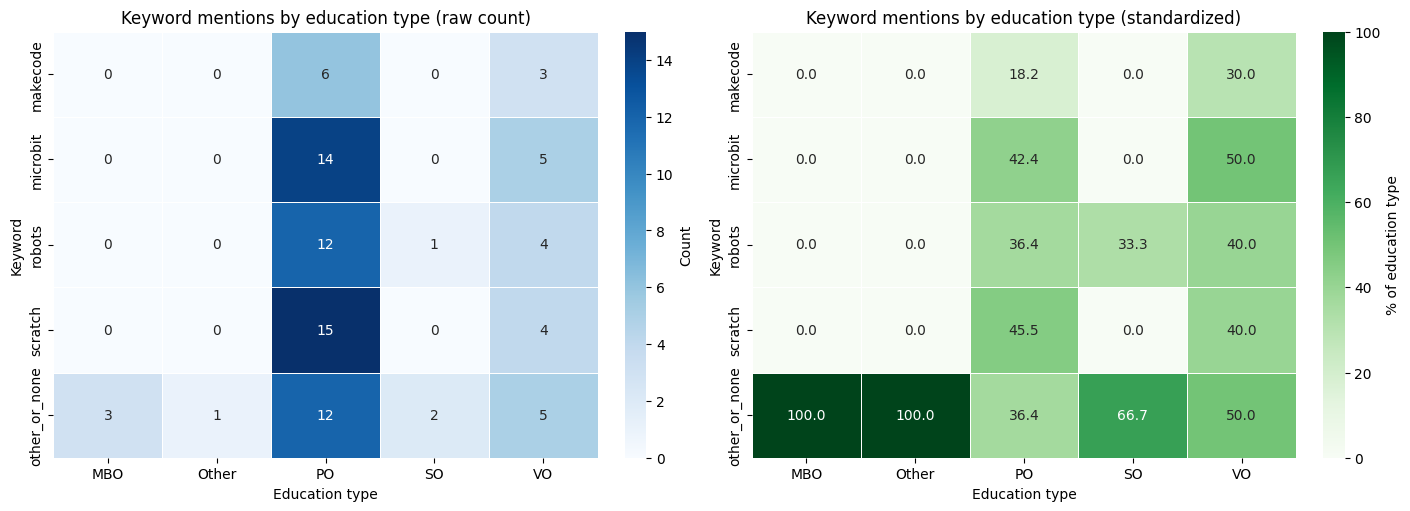

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = mention_by_edu.copy()

# Add "other_or_none" = has other_experiences text, but no tracked keyword match
keyword_cols = list(keyword_patterns.keys())
other_or_none = (
    other_experiences.loc[~other_experiences[keyword_cols].any(axis=1)]
    .groupby("edu_type")
    .size()
    .rename("count")
    .reset_index()
)

if not other_or_none.empty:
    other_or_none["mention"] = "other_or_none"
    other_or_none["edu_total"] = other_or_none["edu_type"].map(edu_totals)
    other_or_none["pct_within_mention"] = (
        other_or_none["count"] / other_or_none["count"].sum() * 100
    ).round(1)
    other_or_none["pct_of_edu"] = (
        other_or_none["count"] / other_or_none["edu_total"] * 100
    ).round(1)

    plot_df = pd.concat([plot_df, other_or_none[plot_df.columns]], ignore_index=True)

edu_order = sorted(edu_totals.index.tolist())
mention_order = [m for m in plot_df["mention"].drop_duplicates() if m != "other_or_none"] + ["other_or_none"]

# Raw counts
count_pivot = (
    plot_df
    .pivot(index="mention", columns="edu_type", values="count")
    .reindex(index=mention_order, columns=edu_order)
    .fillna(0)
)

# Standardized values (% within each education type)
standardized_pivot = (
    plot_df
    .pivot(index="mention", columns="edu_type", values="pct_of_edu")
    .reindex(index=mention_order, columns=edu_order)
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.heatmap(
    count_pivot,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Count"},
    ax=axes[0],
)
axes[0].set_title("Keyword mentions by education type (raw count)")
axes[0].set_xlabel("Education type")
axes[0].set_ylabel("Keyword")

sns.heatmap(
    standardized_pivot,
    annot=True,
    fmt=".1f",
    cmap="Greens",
    linewidths=0.5,
    cbar_kws={"label": "% of education type"},
    ax=axes[1],
)
axes[1].set_title("Keyword mentions by education type (standardized)")
axes[1].set_xlabel("Education type")
axes[1].set_ylabel("Keyword")

plt.show()

# data analysis /Users/lottebecking/Downloads/20250926+gemiddelde_referentieniveaus_per_school_2223_2324_2425_Open_data.ods